In [ ]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum


import training_engine as training_engine 
import inference_engine as inference_engine
from code.rms_norm_file import RMSNorm


MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "vocab_size"  : 2**11,  # 2048
    "num_attn_heads": 2**2, # 4
    "num_layers": 1,
   
    "batch_size"  : 2**4,   # 16
    "learning_rate" : 1e-3,

    "save_path" : "../models/level4_multi_head_attn.pt",
    "loss_history" : "../models/level4_multi_head_attn_loss_history.txt",

}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)




cuda


In [4]:
class Level4MultiHeadAttentionModel(nn.Module):
    """
    Input:
        idx: Long(Int) tensor with shape (batch, seq_len)

    Output:
        logits: Float tensor with shape (batch, seq_len, vocab_size)
    """

    def __init__(self):
        super().__init__()
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.max_seq_len = MODEL_CONFIGS["max_seq_len"]
        self.num_attn_heads = MODEL_CONFIGS["num_attn_heads"]

        # Token Embedding lookup (learnable parameters)
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)

        # Unembedding Projection matrix (learnable parameters)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)

        # pos_enc: (max_seq_len, embed_dim)
        pos_enc = self._build_fixed_sinusoidal_positional_encoding()

        # Register as buffer: non-learnable(no grad flows in)
        self.register_buffer('pos_enc', pos_enc)

        self.rms_norm_1 = RMSNorm(self.embed_dim)
        self.rms_norm_2 = RMSNorm(self.embed_dim)

        self.multi_attn = MultiHeadCausalAttention()


    @staticmethod
    def _build_fixed_sinusoidal_positional_encoding():

        max_seq_len = MODEL_CONFIGS["max_seq_len"]
        embed_dim = MODEL_CONFIGS["embed_dim"]
       
        # position: (max_seq_len,)
        position = torch.arange(max_seq_len, dtype=torch.float)

        # frequencies for each pair of dimensions: (embed_dim // 2,)
        # ω_k = 10000 ^ (-2k / d)
        inv_freq = torch.exp(
            torch.arange(0, embed_dim, 2, dtype=torch.float) *
            (-math.log(10000.0) / embed_dim)
        )

        # Outer product → angles: (max_seq_len, embed_dim // 2)
        angles = einsum(position, inv_freq, "pos, half -> pos half")

        # Build the final PE matrix
        pos_enc = torch.zeros(max_seq_len, embed_dim)
        pos_enc[:, 0::2] = torch.sin(angles)          # even dimensions
        pos_enc[:, 1::2] = torch.cos(angles)          # odd dimensions

        return pos_enc # (max_seq_len, embed_dim)



    def forward(self, idx):
        batch_size, seq_len = idx.shape

        # Look up and add fixed positional encodings
        x_token = self.embed[idx]

        # x_pos: (1, seq_len, embed_dim)
        # add 1 so to broadcast over batch
        x_pos = rearrange(
            self.pos_enc[:seq_len],
            "seq_len embed_dim -> 1 seq_len embed_dim",
        )

        # x: (batch, seq_len, embed_dim)
        x = x_token + x_pos  # PyTorch automatically broadcasts the batch dimension of 1 to batch_size

        # pre-norm attention block.
        # x_norm_1: (batch, seq_len, embed_dim)
        x_norm_1 = self.rms_norm_1(x)

        # attn_out: (batch, seq_len, embed_dim)
        attn_out = self.multi_attn(x_norm_1)

        # Residual connection.
        # x: (batch, seq_len, embed_dim)
        x = x + attn_out

        # x_norm_2: (batch, seq_len, embed_dim)
        x_norm_2 = self.rms_norm_2(x)

        # logits: (batch, seq_len, vocab_size)
        logits = einsum(
            x_norm_2,
            self.unembed,
            "batch seq_len embed_dim, embed_dim vocab_size -> batch seq_len vocab_size",
        )

        return logits



In [ ]:
class MultiHeadCausalAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.num_heads = MODEL_CONFIGS["num_attn_heads"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]


        assert self.embed_dim % self.num_heads == 0, "embed_dim must be divisible by num_heads"

        self.head_dim = self.embed_dim // self.num_heads


        #  query, key, value projections
        self.query_proj = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.key_proj   = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.value_proj = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)

        # output projection
        self.out_proj   = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)



    def forward(self, x):
        batch, seq_len, embed_dim = x.shape

        # project through
        q = einsum(x, self.query_proj, "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out")
        k = einsum(x, self.key_proj,   "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out")
        v = einsum(x, self.value_proj, "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out")


        # split into heads
        q = rearrange(q, "batch seq_len (num_heads head_dim) -> batch num_heads seq_len head_dim", 
                      num_heads=self.num_heads, head_dim=self.head_dim)
        
        k = rearrange(k, "batch seq_len (num_heads head_dim) -> batch num_heads seq_len head_dim", 
                      num_heads=self.num_heads, head_dim=self.head_dim)
        
        v = rearrange(v, "batch seq_len (num_heads head_dim) -> batch num_heads seq_len head_dim", 
                      num_heads=self.num_heads, head_dim=self.head_dim)


        # scaled dot-product attention
        attn_scores = einsum(q, k, 
                             "batch num_heads query_seq head_dim, batch num_heads key_seq head_dim " 
                             "->" 
                             " batch num_heads query_seq key_seq") / math.sqrt(self.head_dim)


        # causal masking
        causal_mask = torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool).triu(diagonal=1)
        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))

        # attention probabilities
        attn_weights = torch.nn.functional.softmax(attn_scores, dim=-1)


        # weighted sum of values
        attn_output = einsum(
            attn_weights, v,
            "batch num_heads query_seq key_seq, batch num_heads key_seq head_dim" 
            "->" 
            "batch num_heads query_seq head_dim"
        )

        # merge heads
        # (batch, num_heads, seq_len, head_dim) -> (batch, seq_len, embed_dim)
        attn_output = rearrange(
            attn_output,
            "batch num_heads seq_len head_dim -> batch seq_len (num_heads head_dim)"
        )



        # Output projection
        output = einsum(
            attn_output, self.out_proj,
            "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out"
        )

        return output


Step 0000 | Batch Loss: 7.6322 nats
Step 0005 | Batch Loss: 7.5840 nats
Step 0010 | Batch Loss: 7.5476 nats
Step 0015 | Batch Loss: 7.4954 nats
Step 0020 | Batch Loss: 7.4469 nats
Step 0025 | Batch Loss: 7.3974 nats
Step 0030 | Batch Loss: 7.3297 nats
Step 0035 | Batch Loss: 7.2871 nats
Step 0040 | Batch Loss: 7.2299 nats
Step 0045 | Batch Loss: 7.2009 nats
Step 0050 | Batch Loss: 7.1647 nats
Step 0055 | Batch Loss: 7.1514 nats
Step 0060 | Batch Loss: 7.1927 nats
Step 0065 | Batch Loss: 7.0998 nats
Step 0070 | Batch Loss: 7.0321 nats
Step 0075 | Batch Loss: 7.0553 nats
Step 0080 | Batch Loss: 7.1122 nats
Step 0085 | Batch Loss: 7.0609 nats
Step 0090 | Batch Loss: 7.1151 nats
Step 0095 | Batch Loss: 7.0404 nats
Step 0099 | Batch Loss: 7.1031 nats

Saving model weights to: ../models/level4_multi_head_attn.pt
Loss history successfully saved to ../models/level4_multi_head_attn_loss_history.txt
Loaded 100 steps from ../models/level4_multi_head_attn_loss_history.txt


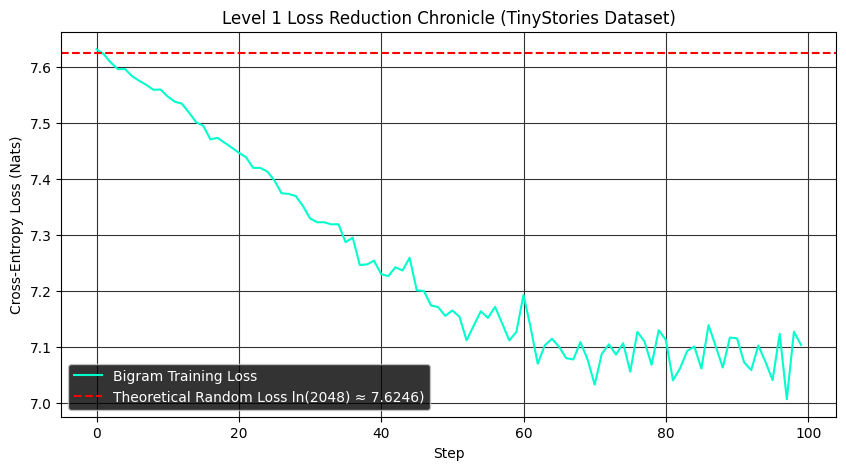

In [6]:
model = Level4MultiHeadAttentionModel()
configs = MODEL_CONFIGS

training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)


In [7]:
training_engine.inspect_weight_file(configs["save_path"], False)

Loaded state_dict from ..\models\level4_multi_head_attn.pt
Number of parameter tensors: 9
Number of parameters: 137,280

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536
pos_enc: shape=(64, 32), dtype=torch.float32, requires_grad=False, numel=2,048
rms_norm_1.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
rms_norm_2.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
multi_attn.query_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
multi_attn.key_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
multi_attn.value_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
multi_attn.out_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
